# HOME CREDIT DEFAULT RISK 

* Prédire la probabilité de défault d'un client qui sollicite un crédit bancaire, afin de décider de l'octroi ou non du crédit demandé

## Imports Librairies

In [4]:
# --- Base ---
import numpy as np
import pandas as pd

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sélection de modèles & validation ---
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score, cross_validate, cross_val_predict

# --- Prétraitement ---
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder, LabelEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

# --- Modèles de classification (scikit-learn) ---
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# --- Modèles de régression (scikit-learn) ---
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# --- (Optionnels) XGBoost / LightGBM / CatBoost : import si installés ---
try:
    from xgboost import XGBClassifier, XGBRegressor
except Exception:
    XGBClassifier = XGBRegressor = None
try:
    from lightgbm import LGBMClassifier, LGBMRegressor
except Exception:
    LGBMClassifier = LGBMRegressor = None
try:
    from catboost import CatBoostClassifier, CatBoostRegressor
except Exception:
    CatBoostClassifier = CatBoostRegressor = None

# --- Métriques : classification & régression ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, classification_report,
    r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
)

# --- Importance des features & interprétabilité ---
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay  # PDP/ICE
# SHAP (si installé) : importance globale & locale
try:
    import shap
except Exception:
    shap = None

from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
precision_score, recall_score,roc_auc_score,
ConfusionMatrixDisplay, classification_report,
precision_recall_curve, auc, roc_curve)

In [5]:
from creditscoring.utils import load_csv
from creditscoring.utils import save_csv

## DATA Understanding : 

* **application_train**: the main training data with information about each loan application at Home Credit. Every loan has its own row and is identified by the feature SK_ID_CURR. The training application data comes with the TARGET indicating 0: the loan was repaid or 1: the loan was not repaid.

* **application_train / application_test** : les données principales d’entraînement et de test contenant des informations sur chaque demande de prêt chez Home Credit. Chaque prêt correspond à une ligne et est identifié par la variable SK_ID_CURR. Les données d’entraînement incluent la variable TARGET indiquant :

0 : le prêt a été remboursé
1 : le prêt n’a pas été remboursé

In [6]:
application_train = load_csv("application_train.csv")
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


**application_test**: the main testing data with information about each loan application at Home Credit. Every loan has its own row and is identified by the feature SK_ID_CURR. The testing application data have the TARGET column.

In [7]:
application_test = load_csv("application_test.csv")
application_test.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


**bureau_balance**: monthly data about the previous credits in bureau. Each row is one month of a previous credit, and a single previous credit can have multiple rows, one for each month of the credit length.

**bureau_balance** : données mensuelles sur les crédits précédents dans bureau. Chaque ligne correspond à un mois d’un crédit précédent, et un crédit précédent unique peut avoir plusieurs lignes (une par mois de la durée du crédit).

In [8]:
bureau_balance = load_csv("bureau_balance.csv")
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


**bureau**: data concerning client's previous credits from other financial institutions. Each previous credit has its own row in bureau, but one loan in the application data can have multiple previous credits.

**bureau** : données concernant les crédits précédents des clients auprès d’autres institutions financières. Chaque crédit précédent correspond à une ligne dans bureau, mais un prêt dans les données application peut correspondre à plusieurs crédits précédents.

In [9]:
bureau = load_csv("bureau.csv")
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


**credit_card_balance**: monthly data about previous credit cards clients have had with Home Credit. Each row is one month of a credit card balance, and a single credit card can have many rows.

**credit_card_balance** : données mensuelles sur les cartes de crédit précédentes que les clients ont eues chez Home Credit. Chaque ligne correspond à un mois du solde de la carte de crédit, et une carte de crédit unique peut avoir plusieurs lignes.

In [10]:
credit_card_balance = load_csv("credit_card_balance.csv")
credit_card_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


**installments_payment**: payment history for previous loans at Home Credit. There is one row for every made payment and one row for every missed payment.

**installments_payment** : historique des paiements des prêts précédents chez Home Credit. Il y a une ligne pour chaque paiement effectué et une ligne pour chaque paiement manqué.

In [11]:
installments_payments = load_csv("installments_payments.csv")
installments_payments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


**POS_CASH_BALANCE**: monthly data about previous point of sale or cash loans clients have had with Home Credit. Each row is one month of a previous point of sale or cash loan, and a single previous loan can have many rows.

**POS_CASH_BALANCE** : données mensuelles sur les prêts précédents au point de vente ou en espèces que les clients ont eus chez Home Credit. Chaque ligne correspond à un mois d’un prêt précédent, et un prêt précédent unique peut avoir plusieurs lignes.

In [12]:
POS_CASH_balance = load_csv("POS_CASH_balance.csv")
POS_CASH_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


**previous_application**: previous applications for loans at Home Credit of clients who have loans in the application data. Each current loan in the application data can have multiple previous loans. Each previous application has one row and is identified by the feature SK_ID_PREV.

**previous_application** : demandes de prêts précédentes chez Home Credit des clients ayant des prêts dans les données application. Chaque prêt actuel dans les données application peut correspondre à plusieurs prêts précédents. Chaque demande précédente correspond à une ligne et est identifiée par la variable SK_ID_PREV.

In [13]:
previous_application = load_csv("previous_application.csv")
previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
dfs_noms = ['application_train', 'application_test', 'bureau_balance','bureau', 'credit_card_balance',
            'installments_payments', 'POS_CASH_balance','previous_application']

dfs = [application_train, application_test, bureau_balance, bureau, credit_card_balance, 
       installments_payments, POS_CASH_balance, previous_application ]

In [15]:
for i in range(len(dfs)):
    print('{}: \n'.format(dfs_noms[i]))
    print('Shape : ',dfs[i].shape,'\n')
    print(dfs[i].info())
    print('\n\n======================================================\n\n')

application_train: 

Shape :  (307511, 122) 

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB
None




application_test: 

Shape :  (48744, 121) 

<class 'pandas.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 121 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), str(16)
memory usage: 51.2 MB
None




bureau_balance: 

Shape :  (27299925, 3) 

<class 'pandas.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype
---  ------          -----
 0   SK_ID_BUREAU    int64
 1   MONTHS_BALANCE  int64
 2   STATUS          str  
dtypes: int64(2), str(1)
memory usage: 650.9 MB
None




bureau: 

Shape :  (1716428, 17) 

<class 'pandas.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype

In [16]:
def data_describe_dict(datasets: dict, top_n_missing: int = 5):
    """
    Analyse plusieurs DataFrames :
    - Nb lignes / colonnes
    - % global de NaN et duplicats
    - Types de colonnes
    - Mémoire
    - Top N colonnes avec le plus de NaN (%)
    """
    summary_dict = {}
    missing_details = {}

    for name, data in datasets.items():
        # résumé global
        summary_dict[name] = [
            data.shape[0],
            data.shape[1],
            data.isna().sum().sum(),
            round(data.isna().sum().sum() / data.size * 100, 2),   # % NaN global
            data.duplicated().sum(),
            round(data.duplicated().sum() / data.shape[0] * 100, 2), # % duplicats
            data.select_dtypes(include=['object']).shape[1],
            data.select_dtypes(include=['float']).shape[1],
            data.select_dtypes(include=['int']).shape[1],
            data.select_dtypes(include=['bool']).shape[1],
            round(data.memory_usage().sum() / 1024**2, 3)
        ]

        # détail colonnes manquantes (%)
        na_pct = (data.isna().sum() / len(data) * 100).sort_values(ascending=False)
        missing_details[name] = na_pct.head(top_n_missing).to_frame(name="%Missing")

    # tableau comparatif global
    summary_table = pd.DataFrame.from_dict(
        data=summary_dict,
        columns=['Rows', 'Columns','NaN', '%NaN_global','Duplicate', '%Duplicate',
                 'object_dtype','float_dtype','int_dtype',
                 'bool_dtype','MB_Memory'],
        orient='index'
    )

    print("=== SUMMARY FILES ===")
    return summary_table, missing_details


# Utilisation : 
datasets = {
    "application_train": application_train,
    "application_test": application_test,
    "bureau_balance": bureau_balance,
    "bureau": bureau,
    "credit_card_balance": credit_card_balance,
    "installments_payments": installments_payments,
    "POS_CASH_balance": POS_CASH_balance,
    "previous_application": previous_application,
}

summary, missing_cols = data_describe_dict(datasets, top_n_missing=15)

# Résumé global
display(summary)

/var/folders/dr/49f4526j7cg4l2f1m55kc8x40000gn/T/ipykernel_62044/675814289.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include=['object']).shape[1],
/var/folders/dr/49f4526j7cg4l2f1m55kc8x40000gn/T/ipykernel_62044/675814289.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pyd

=== SUMMARY FILES ===


/var/folders/dr/49f4526j7cg4l2f1m55kc8x40000gn/T/ipykernel_62044/675814289.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include=['object']).shape[1],


,Rows,Columns,NaN,%NaN_global,Duplicate,%Duplicate,object_dtype,float_dtype,int_dtype,bool_dtype,MB_Memory
application_train,307511,122,9152465,24.40,0,0.0,16,65,41,0,325.216
application_test,48744,121,1404419,23.81,0,0.0,16,65,40,0,51.163
bureau_balance,27299925,3,0,0.00,0,0.0,1,0,2,0,650.881
bureau,1716428,17,3939947,13.50,0,0.0,3,8,6,0,271.485
credit_card_balance,3840312,23,5877356,6.65,0,0.0,1,15,7,0,696.230
installments_payments,13605401,8,5810,0.01,0,0.0,0,5,3,0,830.408
POS_CASH_balance,10001358,8,52158,0.07,0,0.0,1,2,5,0,669.886
previous_application,1670214,37,11109336,17.98,0,0.0,16,15,6,0,671.811


**Remarques :**
* Absence de doublons dans les différents Dataframes.
* Beaucoup de valeurs manquantes sur certains Dataframes ( Train, Previous ...), que nous devons traiter.
* Hormis les DF de train, test, les autres DF ne contiennent pas beaucoup de colonnes. Nous allons analyser le contenu pour envisager les jointures.


In [17]:
for i in range(len(dfs)):
    print("\n=== Colonnes les plus manquantes dans", dfs_noms[i], "===")
    display(missing_cols[dfs_noms[i]]) 
    print('\n\n======================================================\n\n')


=== Colonnes les plus manquantes dans application_train ===


,%Missing
COMMONAREA_MEDI,69.872297
COMMONAREA_AVG,69.872297
COMMONAREA_MODE,69.872297
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
NONLIVINGAPARTMENTS_MEDI,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_MODE,68.354953
LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MEDI,68.354953







=== Colonnes les plus manquantes dans application_test ===


,%Missing
COMMONAREA_AVG,68.716150
COMMONAREA_MODE,68.716150
COMMONAREA_MEDI,68.716150
NONLIVINGAPARTMENTS_AVG,68.412523
NONLIVINGAPARTMENTS_MODE,68.412523
NONLIVINGAPARTMENTS_MEDI,68.412523
FONDKAPREMONT_MODE,67.284179
LIVINGAPARTMENTS_AVG,67.249302
LIVINGAPARTMENTS_MODE,67.249302
LIVINGAPARTMENTS_MEDI,67.249302







=== Colonnes les plus manquantes dans bureau_balance ===


...

,%Missing
DAYS_ENTRY_PAYMENT,0.021352
AMT_PAYMENT,0.021352
SK_ID_PREV,0.000000
SK_ID_CURR,0.000000
NUM_INSTALMENT_VERSION,0.000000
NUM_INSTALMENT_NUMBER,0.000000
DAYS_INSTALMENT,0.000000
AMT_INSTALMENT,0.000000







=== Colonnes les plus manquantes dans POS_CASH_balance ===


,%Missing
CNT_INSTALMENT_FUTURE,0.260835
CNT_INSTALMENT,0.260675
SK_ID_PREV,0.000000
SK_ID_CURR,0.000000
MONTHS_BALANCE,0.000000
NAME_CONTRACT_STATUS,0.000000
SK_DPD,0.000000
SK_DPD_DEF,0.000000







=== Colonnes les plus manquantes dans previous_application ===


,%Missing
RATE_INTEREST_PRIVILEGED,99.643698
RATE_INTEREST_PRIMARY,99.643698
AMT_DOWN_PAYMENT,53.636480
RATE_DOWN_PAYMENT,53.636480
NAME_TYPE_SUITE,49.119754
NFLAG_INSURED_ON_APPROVAL,40.298129
DAYS_TERMINATION,40.298129
DAYS_LAST_DUE,40.298129
DAYS_LAST_DUE_1ST_VERSION,40.298129
DAYS_FIRST_DUE,40.298129


**Remarques**: 
* Il y a des colonnes avec un taux très élévé de valeurs manquantes tous tableaux confondus.
* Nous allons mettre en place la règle suivante : **Si une colonne contient plus de 60% de valeurs manquantes nous allons la supprimer.** Car aucune stratégie d'imputation ne sera valorisante pour la modélisation.

## DATA Viz : 

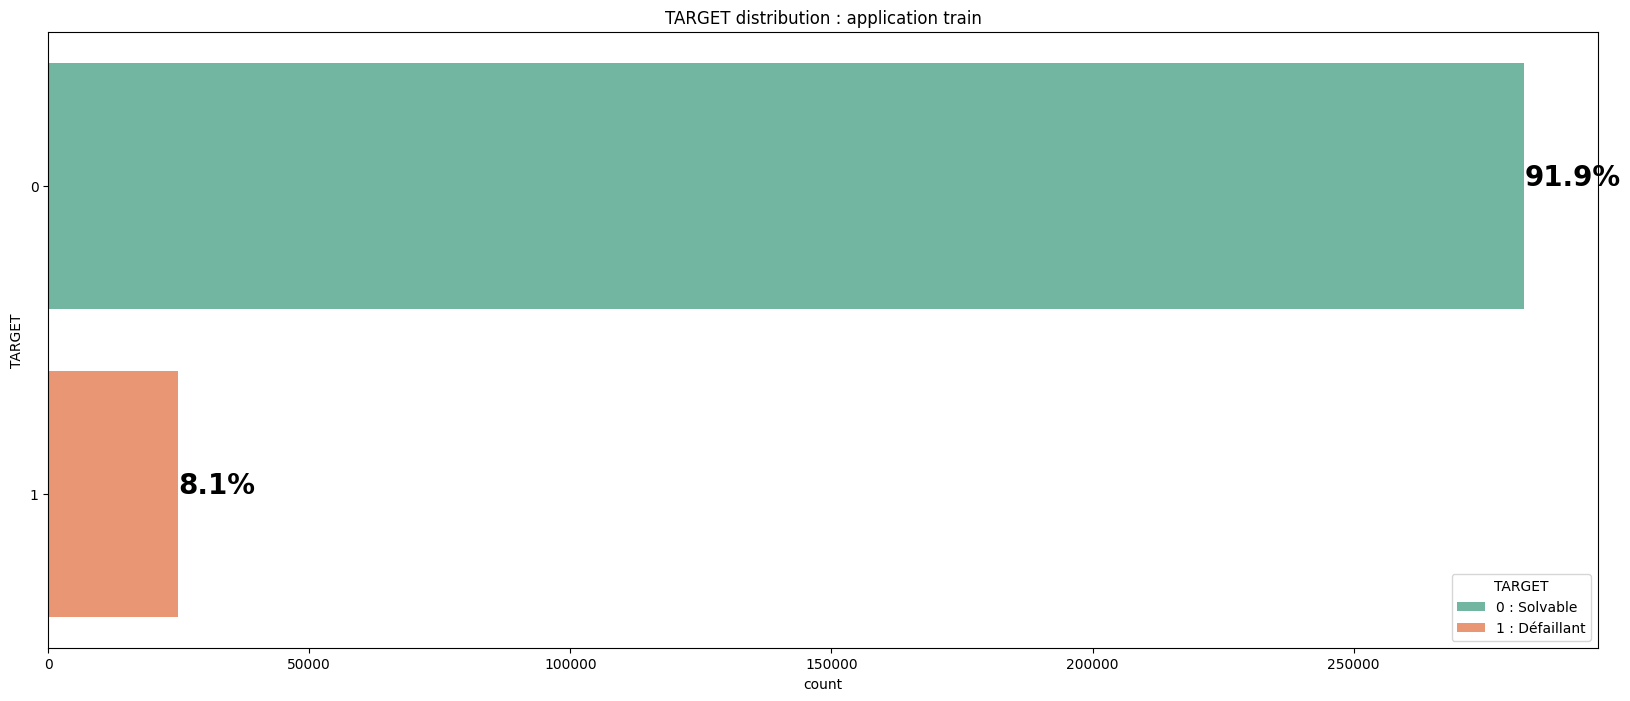

In [18]:
ax, fig = plt.subplots(figsize=(20,8)) 
ax = sns.countplot(y='TARGET', data=application_train, palette='Set2',hue='TARGET', legend=False )
ax.set_title("TARGET distribution : application train")

for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width()/len(application_train.TARGET))
        x = p.get_x() + p.get_width()
        y = p.get_y() + p.get_height()/2
        ax.annotate(percentage, (x, y), fontsize=20, fontweight='bold')
plt.legend(title='TARGET', labels=['0 : Solvable', '1 : Défaillant'])

plt.show()

**Nous remarquons un déséquilibre entre les deux classes. La classe que nous recherchons à prédire est minoritaire ( 1 : Défaillants). Point à retenir pour la modélisation.**

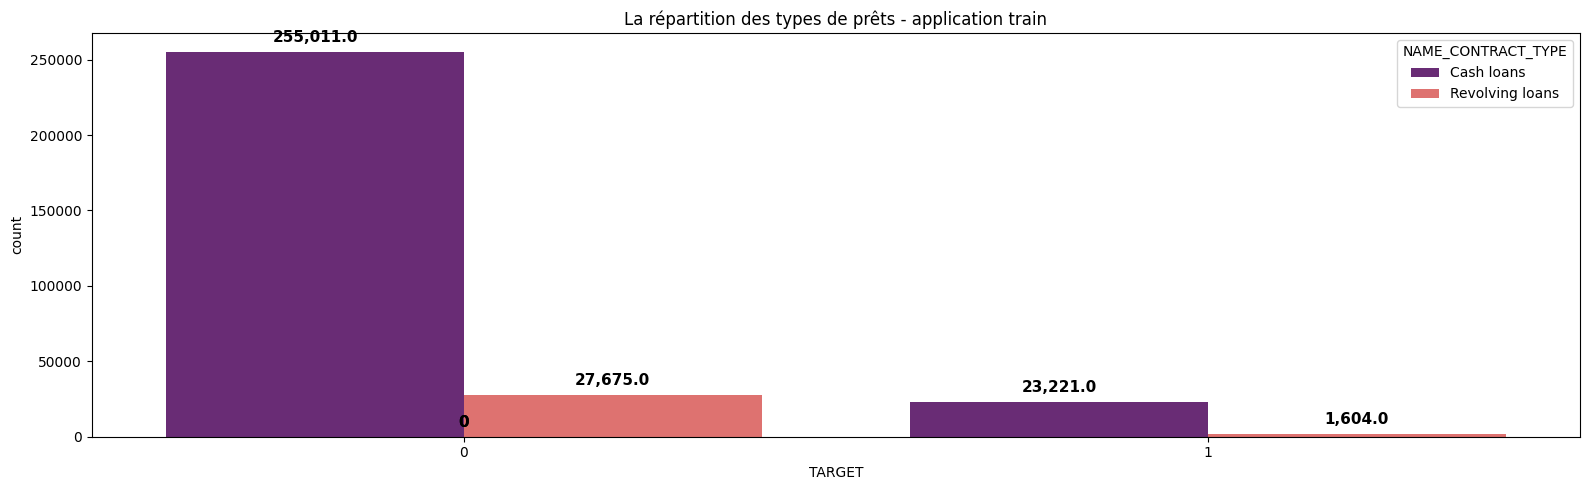

In [19]:
fig = plt.figure(figsize=(16, 5))
ax = sns.countplot(x='TARGET', hue='NAME_CONTRACT_TYPE', data=application_train, palette='magma')
plt.title('La répartition des types de prêts - application train', color='black')
plt.tight_layout()

#Ajouter les totaux sur chaque barre
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',  # nombre avec séparateur de milliers
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

***Nos données portent plus sur les Cash loans plutôt que les Revolving loans.**

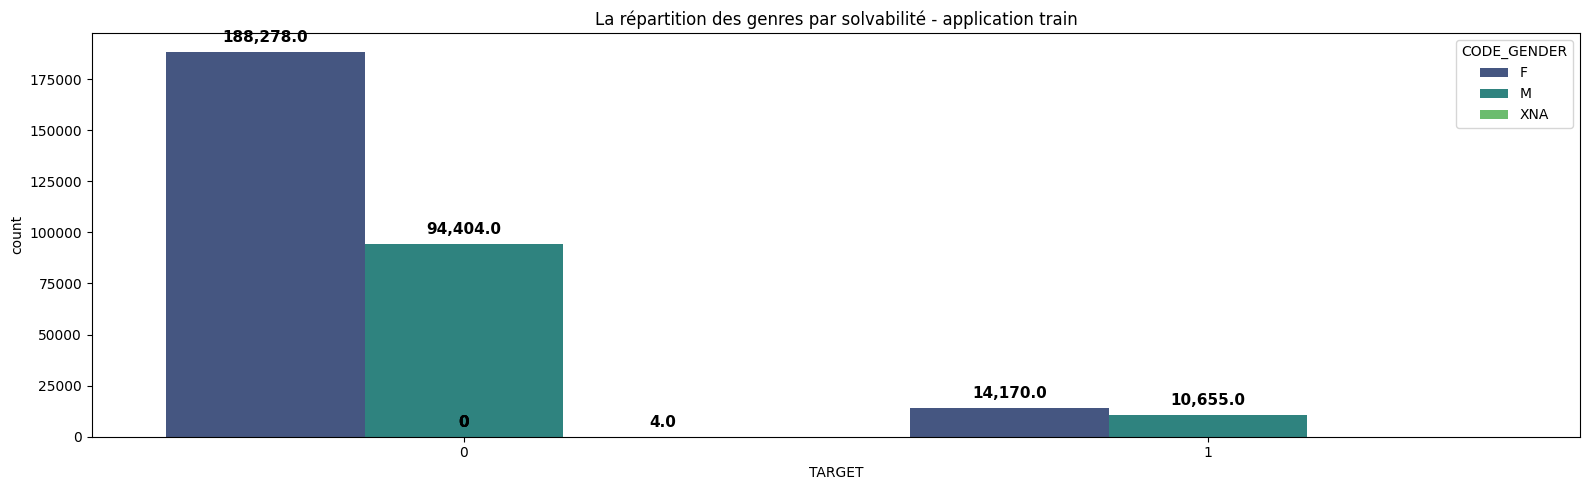

In [20]:
fig = plt.figure(figsize=(16, 5))
ax = sns.countplot(x='TARGET', hue='CODE_GENDER', data=application_train, palette='viridis')
plt.title('La répartition des genres par solvabilité - application train', color='black')
plt.tight_layout()

#Ajouter les totaux sur chaque barre
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',  # nombre avec séparateur de milliers
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

**La population d'emprunteurs étudiée est composée de plus de femmes que d'hommes.**

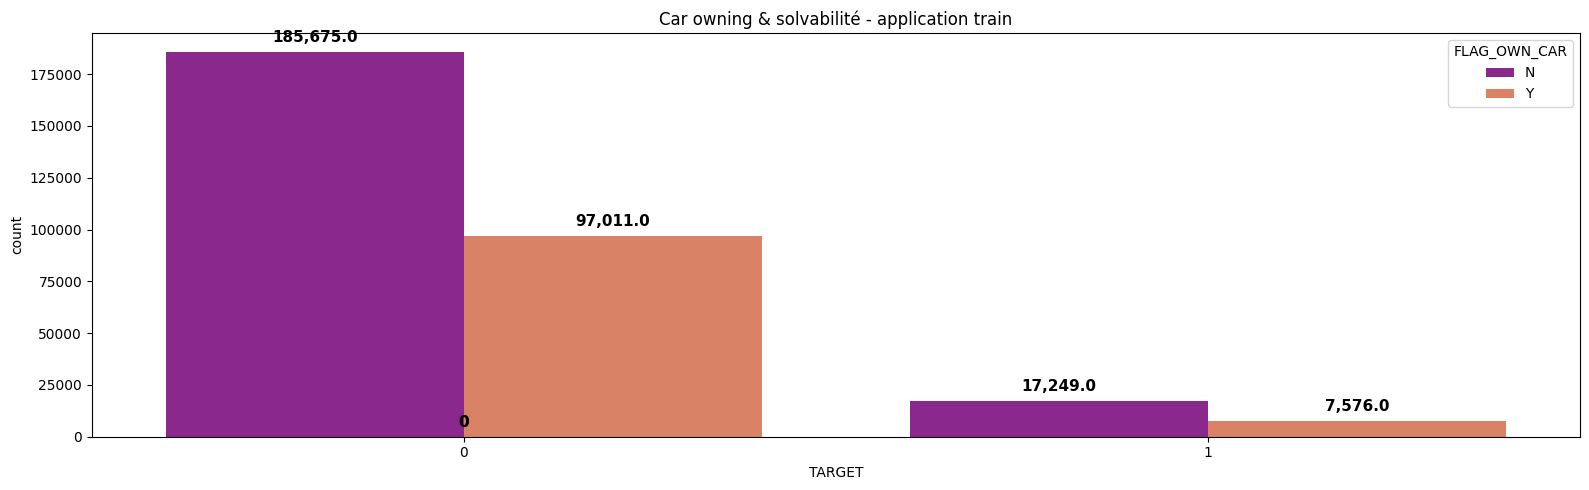

In [21]:
fig = plt.figure(figsize=(16, 5))
ax = sns.countplot(x='TARGET', hue='FLAG_OWN_CAR', data=application_train, palette='plasma')
plt.title('Car owning & solvabilité - application train', color='black')
plt.tight_layout()

#Ajouter les totaux sur chaque barre
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',  # nombre avec séparateur de milliers
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

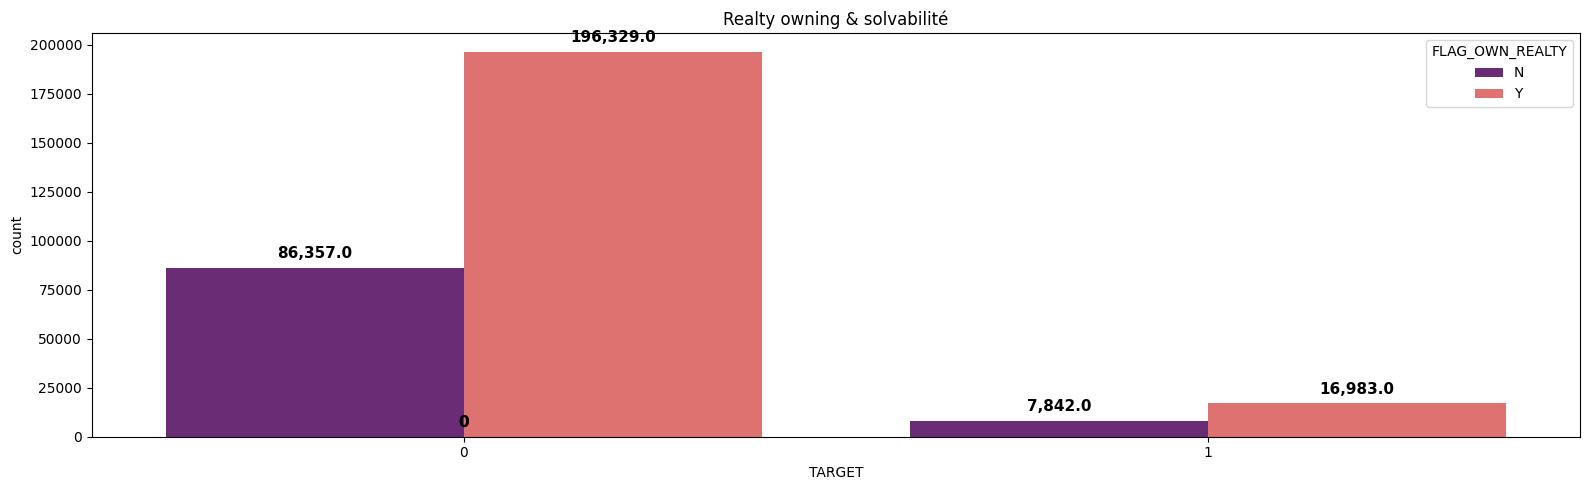

In [22]:
fig = plt.figure(figsize=(16, 5))
ax = sns.countplot(x='TARGET', hue='FLAG_OWN_REALTY', data=application_train, palette="magma")
plt.title('Realty owning & solvabilité', color='black')

plt.tight_layout()

#Ajouter les totaux sur chaque barre
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',  # nombre avec séparateur de milliers
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

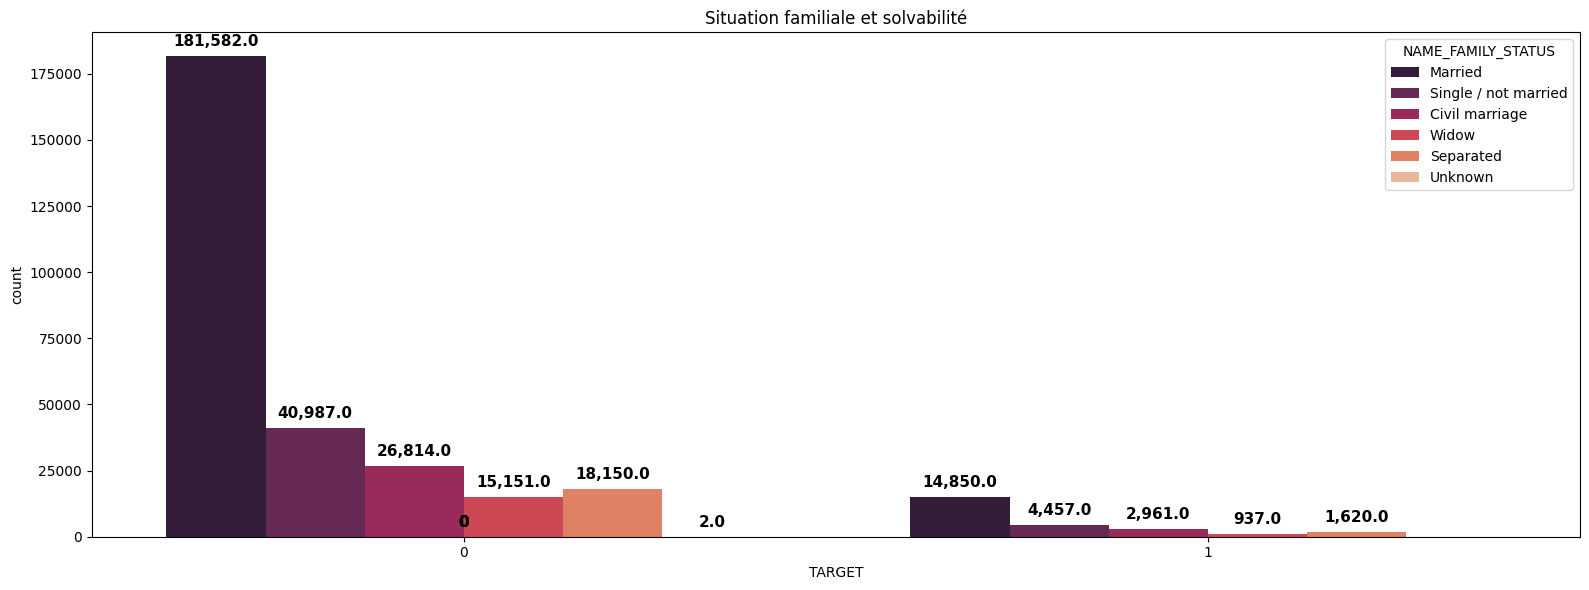

In [23]:
fig = plt.figure(figsize=(16,6))
ax = sns.countplot(x='TARGET', hue='NAME_FAMILY_STATUS', data=application_train, palette="rocket")
plt.title('Situation familiale et solvabilité', color = 'black')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',  # nombre avec séparateur de milliers
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()

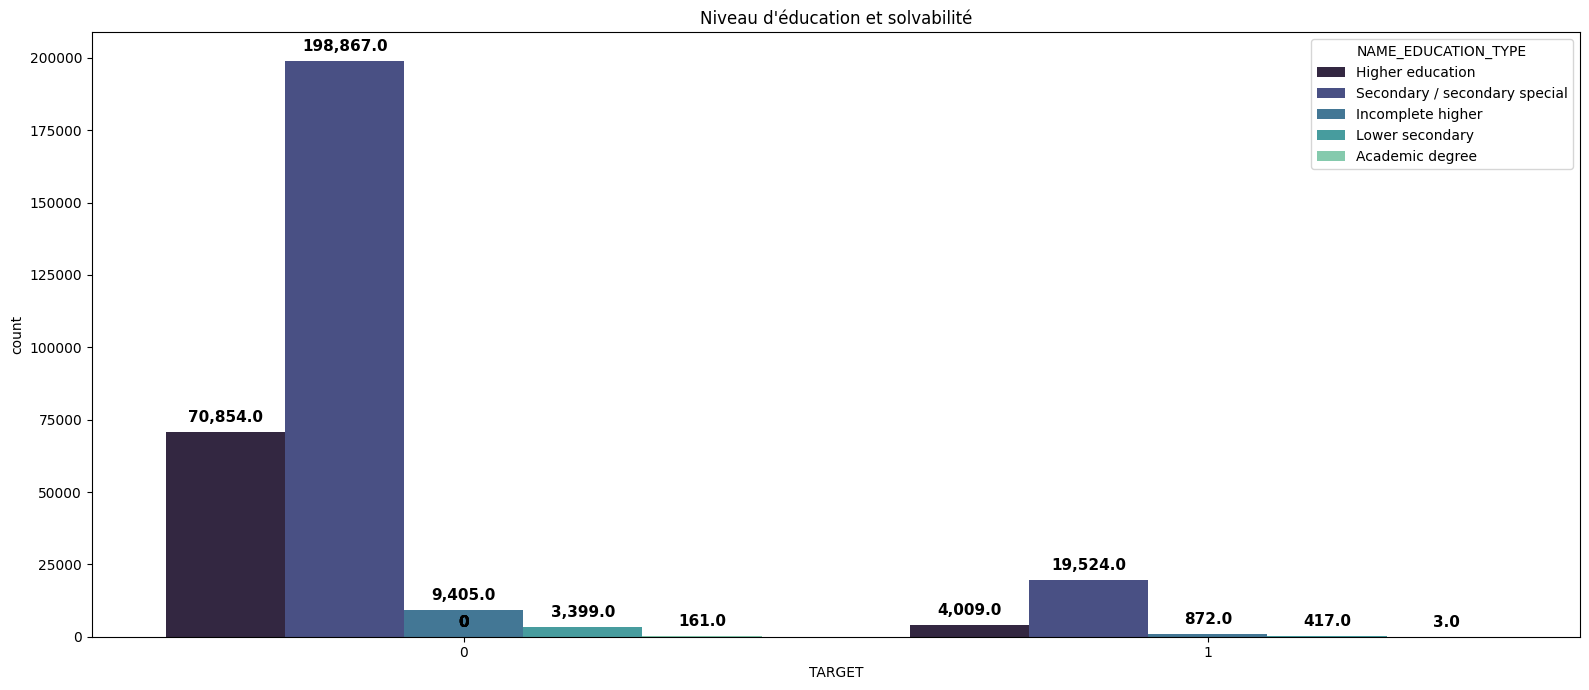

In [24]:
fig = plt.figure(figsize=(16,7))
ax = sns.countplot(x='TARGET', hue='NAME_EDUCATION_TYPE', data=application_train, palette="mako")
plt.title("Niveau d'éducation et solvabilité", color = 'black')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',  # nombre avec séparateur de milliers
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()

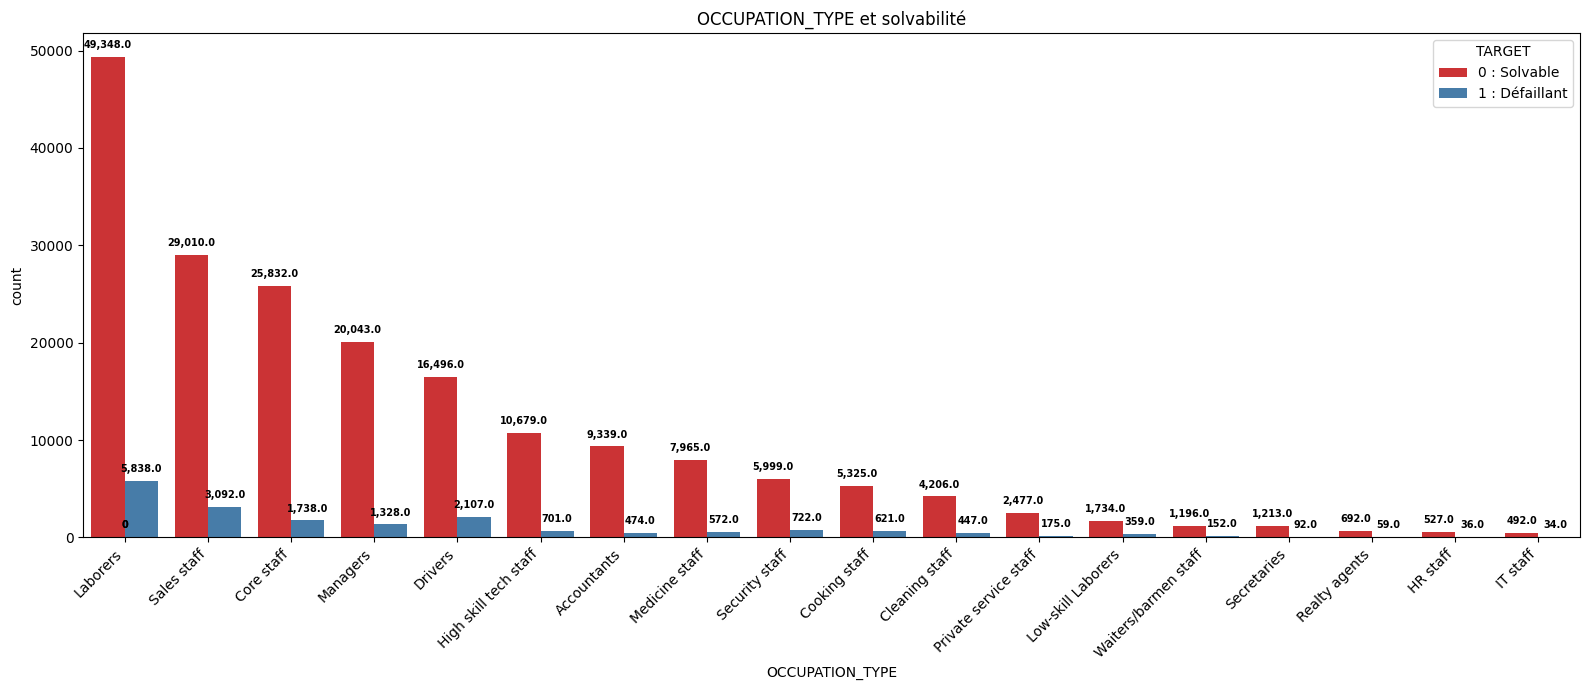

In [25]:
occupation_order = (application_train['OCCUPATION_TYPE'].value_counts().sort_values(ascending=False).index)

fig = plt.figure(figsize=(16, 7))
ax = sns.countplot(x='OCCUPATION_TYPE',hue='TARGET',data=application_train,order=occupation_order, palette="Set1")
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',  # nombre avec séparateur de milliers
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=7, fontweight='bold',
                color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('OCCUPATION_TYPE et solvabilité', color='black')
plt.legend(title='TARGET', labels=['0 : Solvable', '1 : Défaillant'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

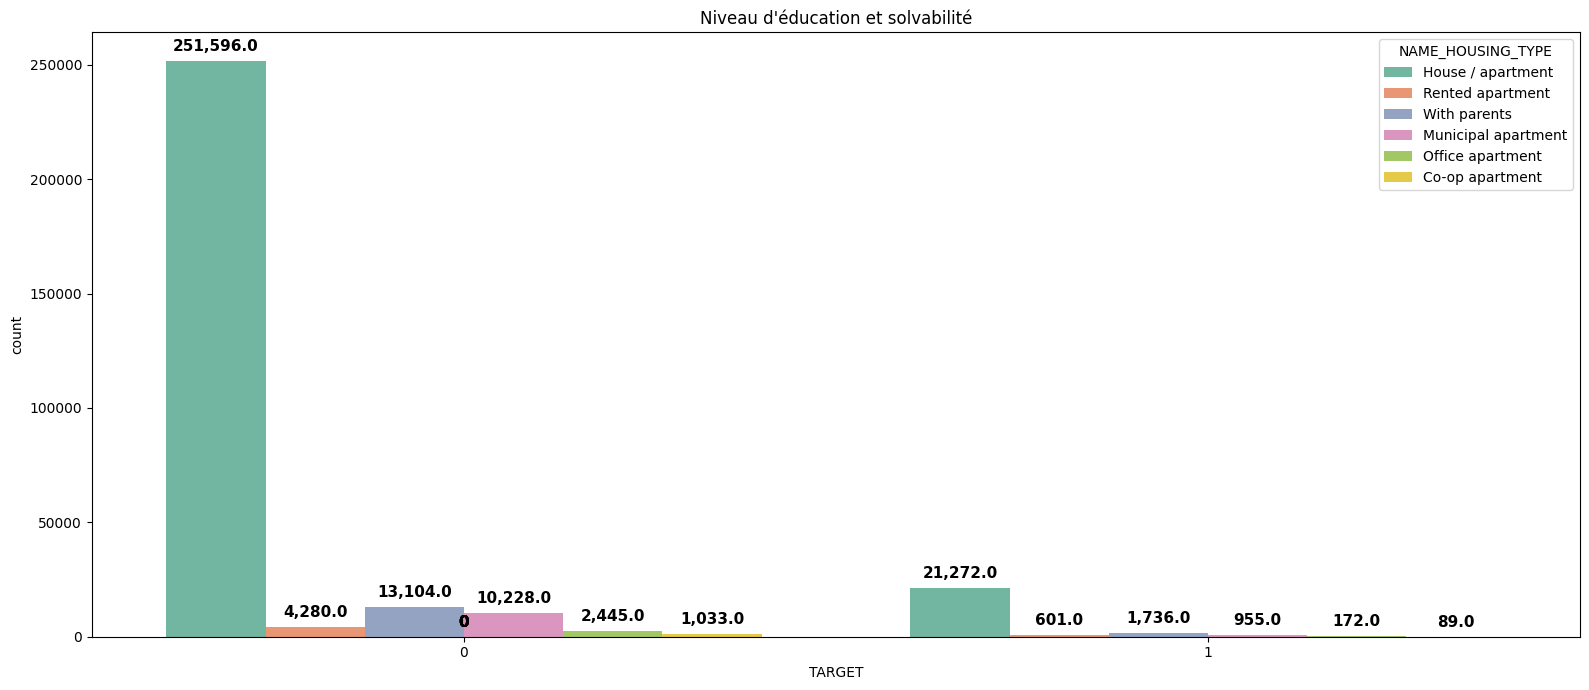

In [26]:
fig = plt.figure(figsize=(16,7))
ax = sns.countplot(x='TARGET', hue='NAME_HOUSING_TYPE', data=application_train, palette="Set2")
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',  # nombre avec séparateur de milliers
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                color='black', xytext=(0, 5),
                textcoords='offset points')
plt.title("Niveau d'éducation et solvabilité", color = 'black')
plt.tight_layout()
plt.show()

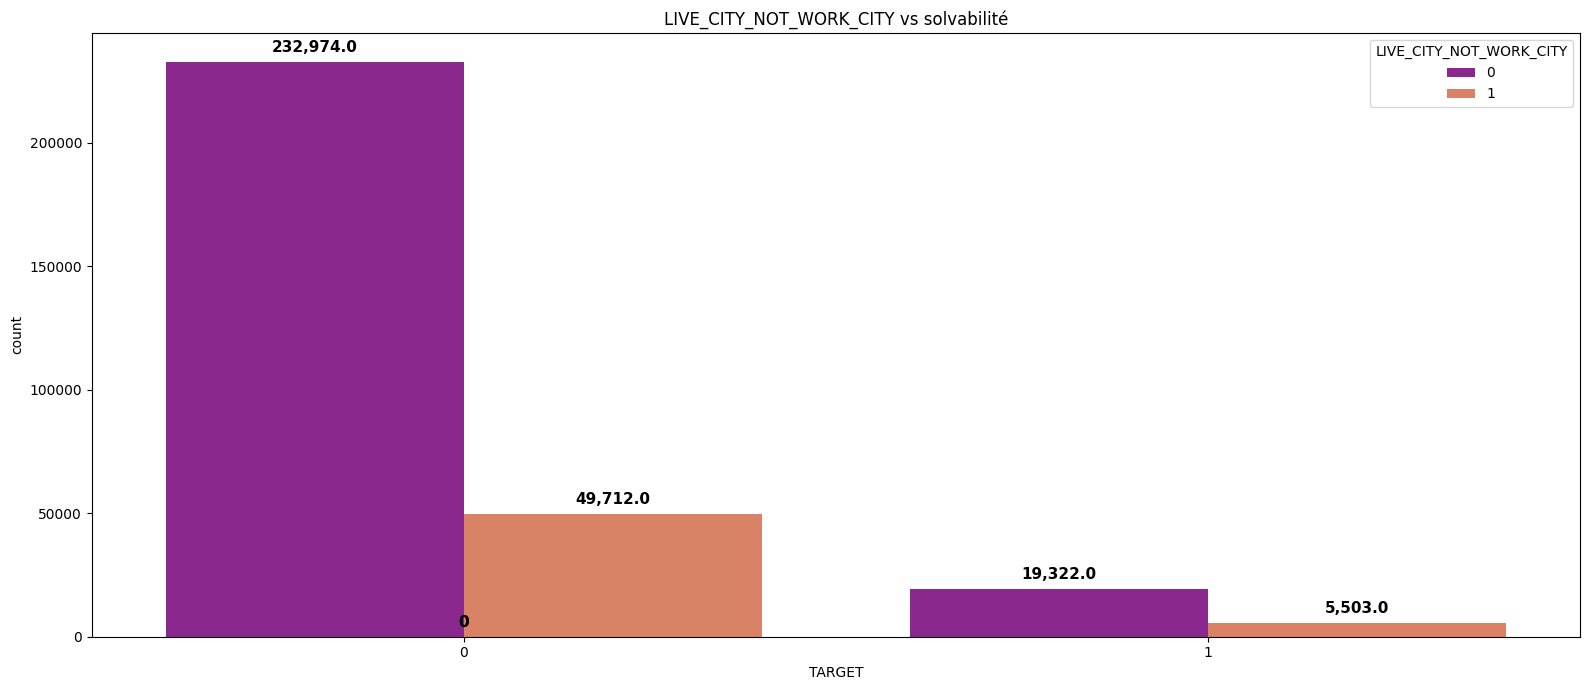

In [27]:
plt.figure(figsize=(16,7))
ax = sns.countplot(x='TARGET', hue='LIVE_CITY_NOT_WORK_CITY', data=application_train, palette="plasma")
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',  # nombre avec séparateur de milliers
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                color='black', xytext=(0, 5),
                textcoords='offset points')
plt.title("LIVE_CITY_NOT_WORK_CITY vs solvabilité", color = 'black')
plt.tight_layout()
plt.show()


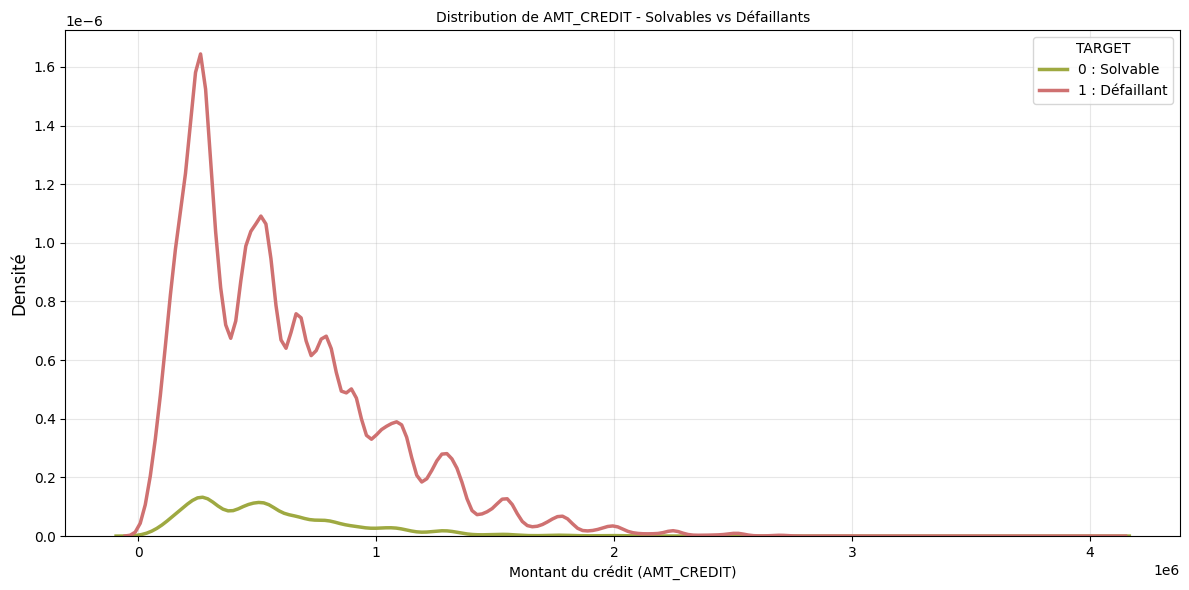

In [28]:
plt.figure(figsize=(12, 6))

# Créer les courbes de densité pour chaque target
sns.kdeplot(data=application_train, 
            x='AMT_CREDIT', 
            hue='TARGET',
            palette={0: "#CF7171", 1: "#9EA941"},
            linewidth=2.5)

plt.title('Distribution de AMT_CREDIT - Solvables vs Défaillants', fontsize=10)
plt.xlabel('Montant du crédit (AMT_CREDIT)', fontsize=10)
plt.ylabel('Densité', fontsize=12)
plt.legend(title='TARGET', labels=['0 : Solvable', '1 : Défaillant'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Les défaillants empruntent des sommes beaucoup plus élevées que les solvables .**

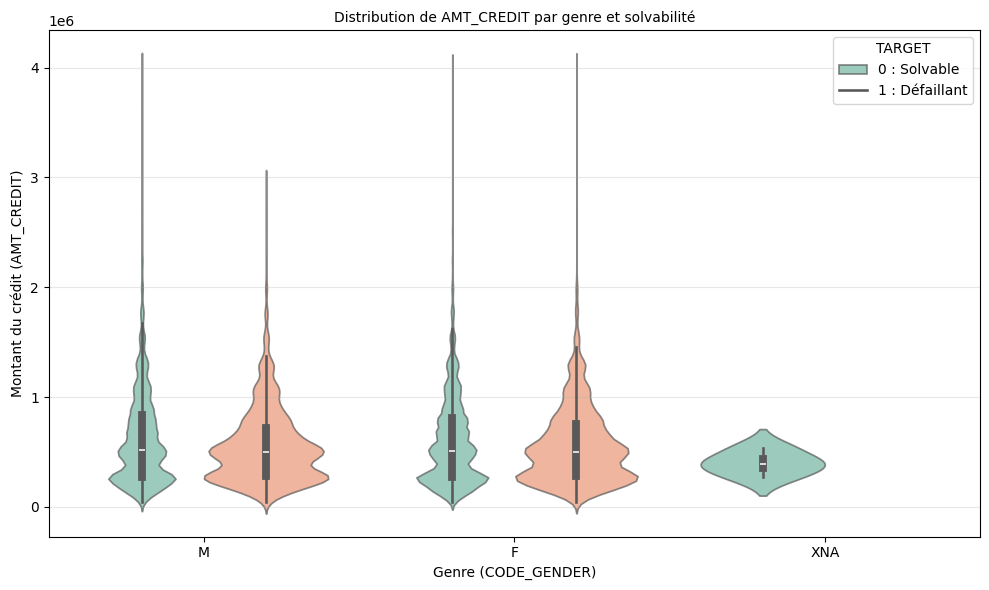

In [29]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=application_train, 
               x='CODE_GENDER', 
               y='AMT_CREDIT', 
               hue='TARGET',
               palette='Set2',
               split=False,
               inner='box', 
               alpha=0.7)
plt.title('Distribution de AMT_CREDIT par genre et solvabilité', fontsize=10)
plt.xlabel('Genre (CODE_GENDER)', fontsize=10)
plt.ylabel('Montant du crédit (AMT_CREDIT)', fontsize=10)
plt.legend(title='TARGET', labels=['0 : Solvable', '1 : Défaillant'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

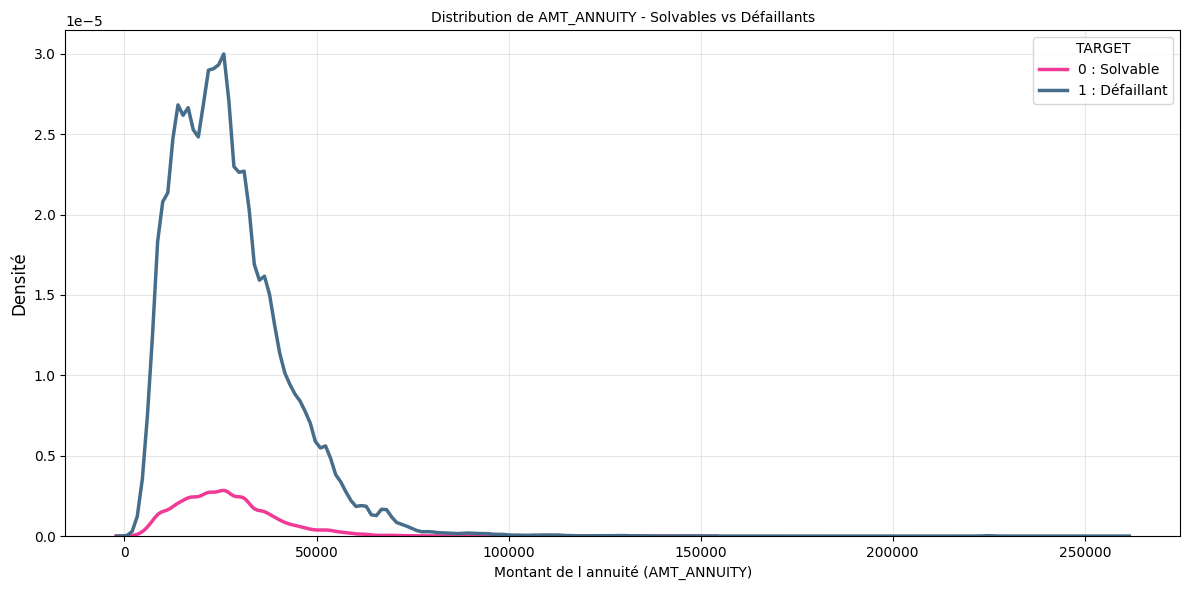

In [30]:
plt.figure(figsize=(12, 6))

# Créer les courbes de densité pour chaque target
sns.kdeplot(data=application_train, 
            x='AMT_ANNUITY', 
            hue='TARGET',
            palette={0: "#466D8A", 1: "#F03A95"},
            linewidth=2.5)

plt.title('Distribution de AMT_ANNUITY - Solvables vs Défaillants', fontsize=10)
plt.xlabel('Montant de l annuité (AMT_ANNUITY)', fontsize=10)
plt.ylabel('Densité', fontsize=12)
plt.legend(title='TARGET', labels=['0 : Solvable', '1 : Défaillant'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Les annuités de crédit des emprunteurs défaillants sont plus élevées que celles des emprunteurs solvables. Ceci est logique car les montants empruntés sont également proportionnellement plus élevés .**

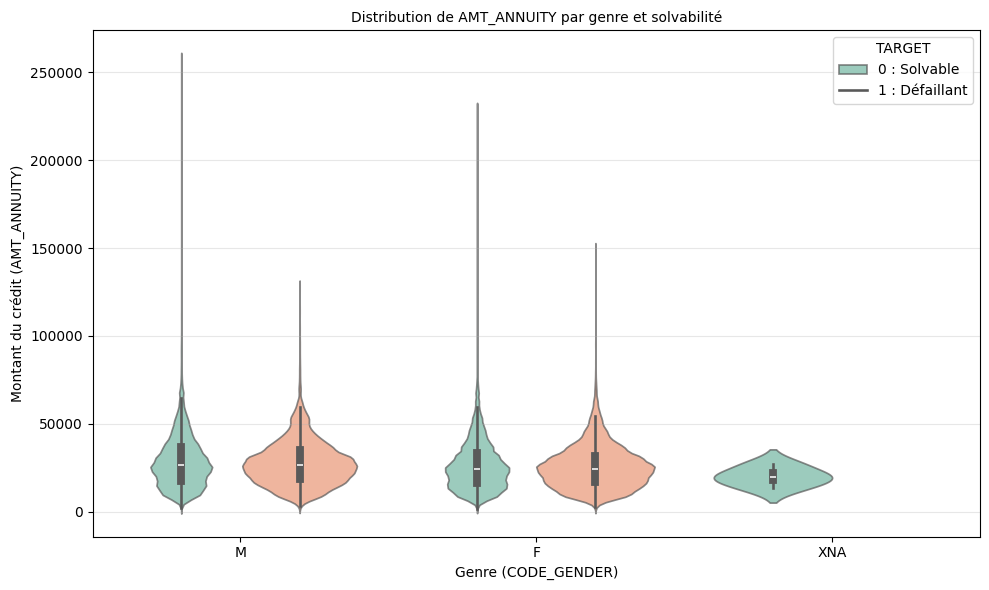

In [31]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=application_train, 
               x='CODE_GENDER', 
               y='AMT_ANNUITY', 
               hue='TARGET',
               palette='Set2',
               split=False,
               inner='box', 
               alpha=0.7)
plt.title('Distribution de AMT_ANNUITY par genre et solvabilité', fontsize=10)
plt.xlabel('Genre (CODE_GENDER)', fontsize=10)
plt.ylabel('Montant du crédit (AMT_ANNUITY)', fontsize=10)
plt.legend(title='TARGET', labels=['0 : Solvable', '1 : Défaillant'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

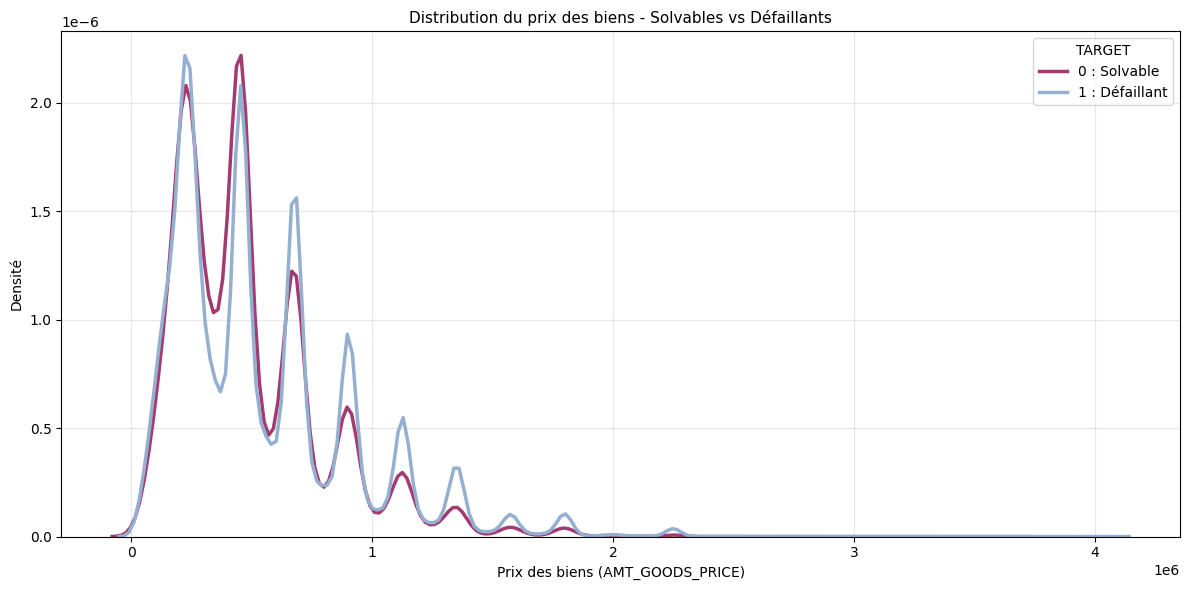

In [32]:
plt.figure(figsize=(12, 6))
# Créer les courbes de densité pour chaque target
sns.kdeplot(data=application_train, 
            x='AMT_GOODS_PRICE', 
            hue='TARGET',
            palette={0: "#94AFD0", 1: "#A23B72"},
            linewidth=2.5,
            common_norm=False)  # Normalise chaque groupe indépendamment
plt.title('Distribution du prix des biens - Solvables vs Défaillants', 
          fontsize=11)
plt.xlabel('Prix des biens (AMT_GOODS_PRICE)', fontsize=10)
plt.ylabel('Densité', fontsize=10)
plt.legend(title='TARGET', labels=['0 : Solvable', '1 : Défaillant'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Les prix des biens financés sont proportionnelles entres les 2 catégories, avec des pics pour les défaillants.**

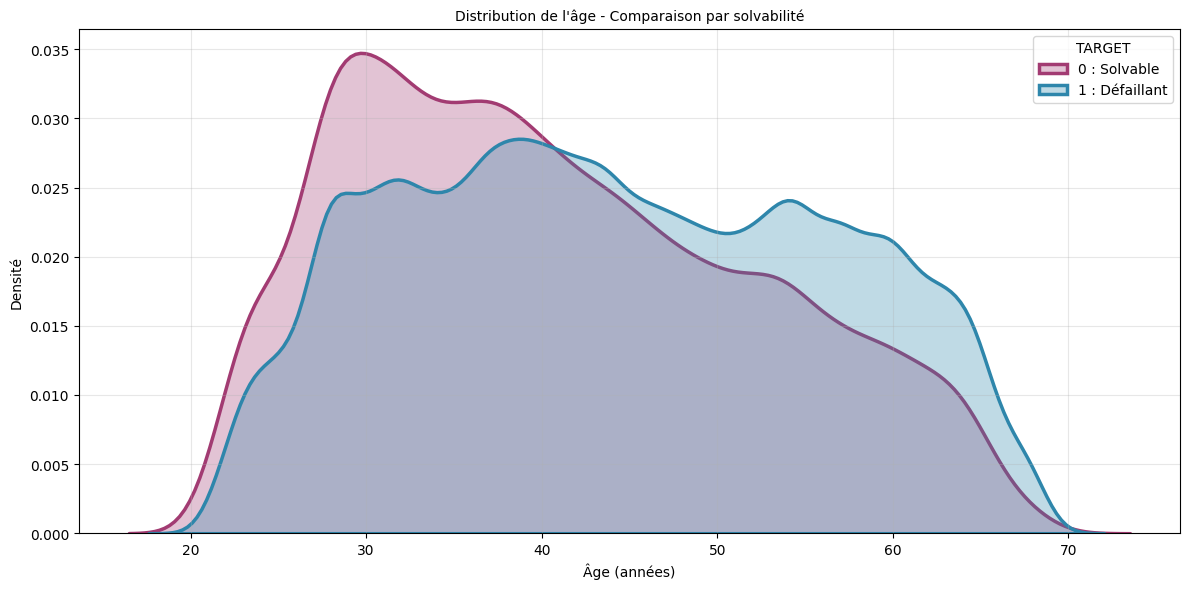

In [33]:
# Créer un DataFrame pour faciliter l'utilisation de hue
age_data = pd.DataFrame({
    'Age': np.abs(application_train['DAYS_BIRTH']) / 365,
    'TARGET': application_train['TARGET']
})

plt.figure(figsize=(12, 6))

# Utiliser hue pour différencier les groupes
sns.kdeplot(data=age_data, 
            x='Age', 
            hue='TARGET',
            palette={0: '#2E86AB', 1: '#A23B72'},
            linewidth=2.5,
            fill=True,
            alpha=0.3,
            common_norm=False)  # Normalise chaque groupe indépendamment

plt.title('Distribution de l\'âge - Comparaison par solvabilité', fontsize=10)
plt.xlabel('Âge (années)', fontsize=10)
plt.ylabel('Densité', fontsize=10)
plt.legend(title='TARGET', labels=['0 : Solvable', '1 : Défaillant'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

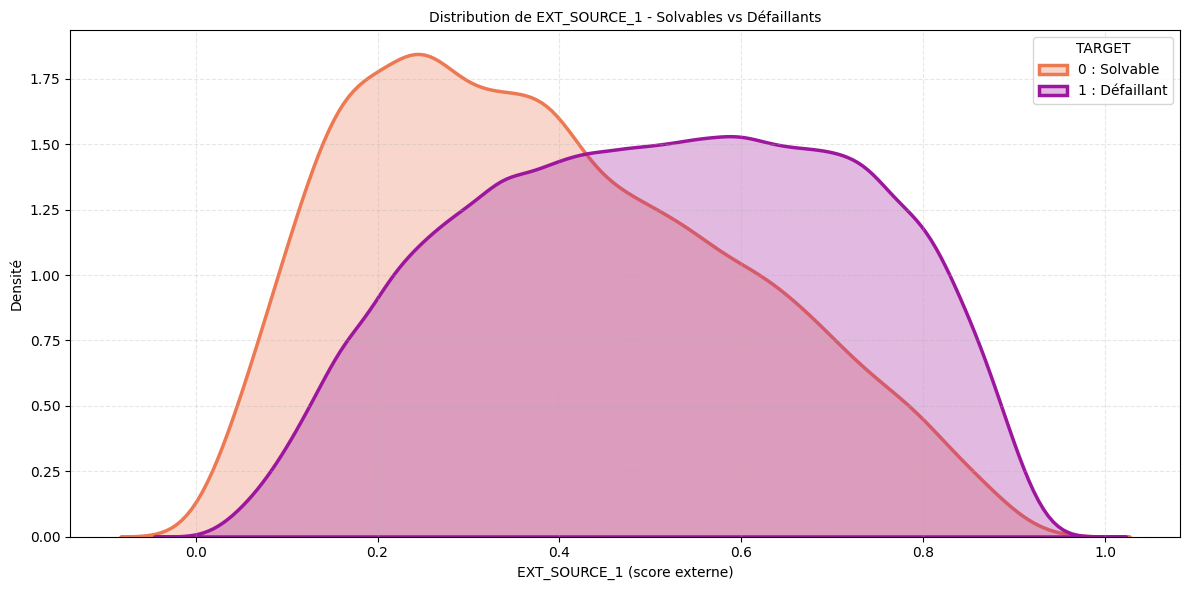

In [34]:
plt.figure(figsize=(12, 6))
# Créer les courbes de densité pour EXT_SOURCE_1
sns.kdeplot(data=application_train, 
            x='EXT_SOURCE_1', 
            hue='TARGET',
            palette="plasma",
            linewidth=2.5,
            fill=True,
            alpha=0.3,
            common_norm=False)  # Normalise chaque groupe indépendamment

plt.title('Distribution de EXT_SOURCE_1 - Solvables vs Défaillants', 
          fontsize=10)
plt.xlabel('EXT_SOURCE_1 (score externe)', fontsize=10)
plt.ylabel('Densité', fontsize=10)
plt.legend(title='TARGET', labels=['0 : Solvable', '1 : Défaillant'])
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

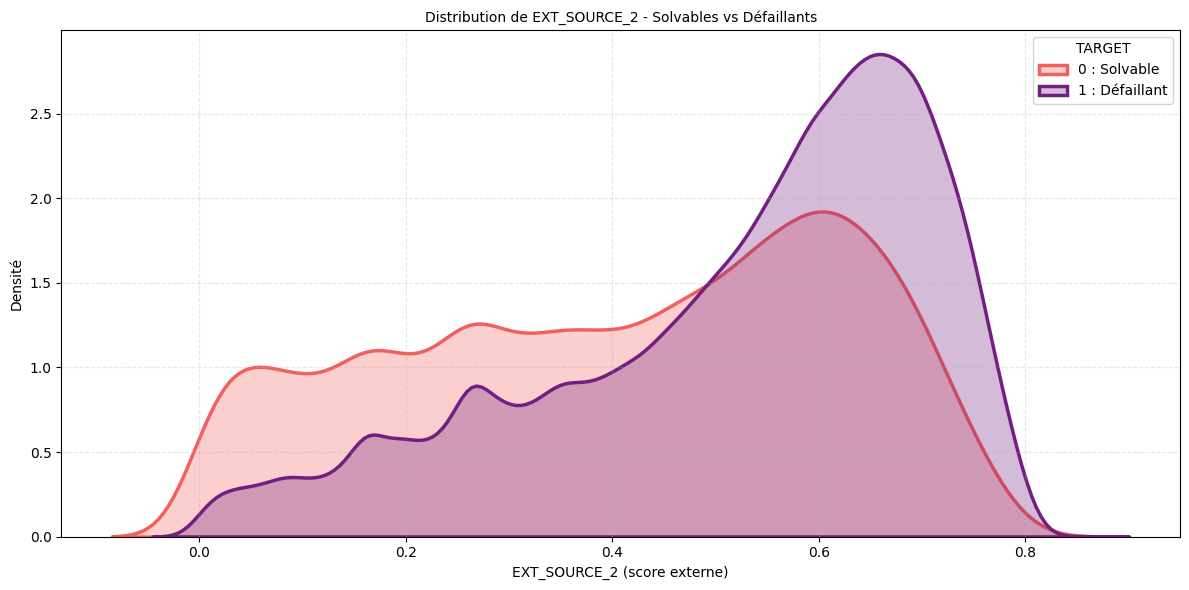

In [35]:
plt.figure(figsize=(12, 6))
# Créer les courbes de densité pour EXT_SOURCE_2
sns.kdeplot(data=application_train, 
            x='EXT_SOURCE_2', 
            hue='TARGET',
            palette="magma",
            linewidth=2.5,
            fill=True,
            alpha=0.3,
            common_norm=False)  # Normalise chaque groupe indépendamment

plt.title('Distribution de EXT_SOURCE_2 - Solvables vs Défaillants', 
          fontsize=10)
plt.xlabel('EXT_SOURCE_2 (score externe)', fontsize=10)
plt.ylabel('Densité', fontsize=10)
plt.legend(title='TARGET', labels=['0 : Solvable', '1 : Défaillant'])
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

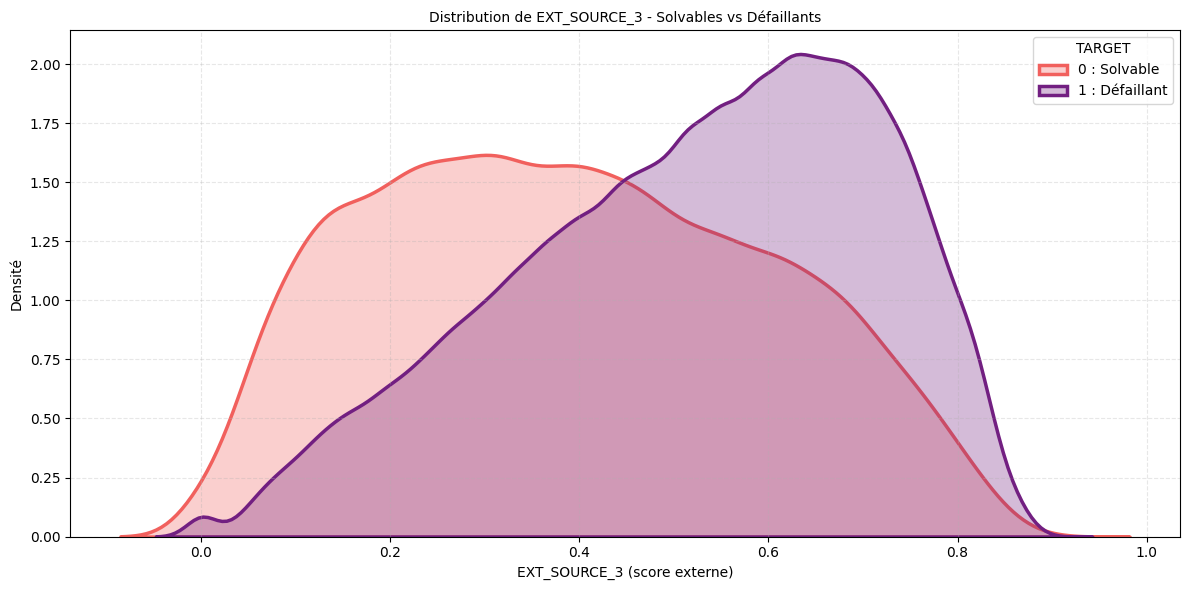

In [36]:
plt.figure(figsize=(12, 6))
# Créer les courbes de densité pour EXT_SOURCE_3
sns.kdeplot(data=application_train, 
            x='EXT_SOURCE_3', 
            hue='TARGET',
            palette="magma",
            linewidth=2.5,
            fill=True,
            alpha=0.3,
            common_norm=False)  # Normalise chaque groupe indépendamment

plt.title('Distribution de EXT_SOURCE_3 - Solvables vs Défaillants', 
          fontsize=10)
plt.xlabel('EXT_SOURCE_3 (score externe)', fontsize=10)
plt.ylabel('Densité', fontsize=10)
plt.legend(title='TARGET', labels=['0 : Solvable', '1 : Défaillant'])
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Feature engineering & MERGING

### Fusion application_train & application_test

* **Nous allons commencer par fusionner application_train et application_test, puis les fusionner avec les autres tableau en utilisant la clé SK_ID_CURR, et ensuite nous allons de nouveau séparer en 2 datasets pour utiliser celui qui contient TARGET info pour l'entrainement, celui qui ne contient pas TARGET pour générer les prédictions.**

In [37]:
# application_train - avec TARGET (la variable à prédire)
# application_test - sans TARGET
# Avant preprocessing: concaténer pour appliquer les mêmes transformations
fusion1 = pd.concat([application_train, application_test], 
                   axis=0, 
                   join='outer', 
                   ignore_index=True)

In [38]:
fusion1.shape

(356255, 122)

### Fusion previous_application

* **Feature engineering previous_application :**

In [39]:
previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
#Nous créons de nouvelles features à partir des informations les plus importantes de previous

previous_application["APP_CREDIT_RATIO"]       = previous_application["AMT_APPLICATION"] / (previous_application["AMT_CREDIT"] + 1)
previous_application["DOWN_PAYMENT_RATIO"]     = previous_application["AMT_DOWN_PAYMENT"] / (previous_application["AMT_CREDIT"] + 1)
previous_application["ANNUITY_CREDIT_RATIO"]   = previous_application["AMT_ANNUITY"] / (previous_application["AMT_CREDIT"] + 1)
previous_application["APPROVED"]               = (previous_application["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
previous_application["REFUSED"]                = (previous_application["NAME_CONTRACT_STATUS"] == "Refused").astype(int)

In [41]:
# Nous allons aggréger car dans previous nous allons plusieurs loans par ID client 

agg_prev = previous_application.groupby("SK_ID_CURR").agg(
        PREV_COUNT                = ("SK_ID_PREV",            "count"),
        PREV_APPROVED_RATE        = ("APPROVED",              "mean"),
        PREV_REFUSED_RATE         = ("REFUSED",               "mean"),
        PREV_APP_CREDIT_RATIO_MEAN= ("APP_CREDIT_RATIO",      "mean"),
        PREV_ANNUITY_MEAN         = ("AMT_ANNUITY",           "mean"),
        PREV_CREDIT_MEAN          = ("AMT_CREDIT",            "mean"),
        PREV_DAYS_DECISION_MEAN   = ("DAYS_DECISION",         "mean"),
        PREV_DAYS_DECISION_MIN    = ("DAYS_DECISION",         "min"),
        PREV_GOODS_PRICE_MEAN     = ("AMT_GOODS_PRICE",       "mean"),
    ).reset_index()

In [42]:
agg_prev.head()

,SK_ID_CURR,PREV_COUNT,PREV_APPROVED_RATE,PREV_REFUSED_RATE,PREV_APP_CREDIT_RATIO_MEAN,PREV_ANNUITY_MEAN,PREV_CREDIT_MEAN,PREV_DAYS_DECISION_MEAN,PREV_DAYS_DECISION_MIN,PREV_GOODS_PRICE_MEAN
0,100001,1,1.0,0.0,1.044035,3951.000,23787.00,-1740.0,-1740,24835.5
1,100002,1,1.0,0.0,0.999994,9251.775,179055.00,-606.0,-606,179055.0
2,100003,3,1.0,0.0,0.949323,56553.990,484191.00,-1305.0,-2341,435436.5
3,100004,1,1.0,0.0,1.207639,5357.250,20106.00,-815.0,-815,24282.0
4,100005,2,0.5,0.0,0.555573,4813.200,20076.75,-536.0,-757,44617.5


* **Fusion 2 : app train & app test avec previous app:**

In [43]:
fusion1.shape

(356255, 122)

In [44]:
fusion2 = fusion1.merge(agg_prev, on='SK_ID_CURR', how='left', suffixes=('', '_dup'))
fusion2.shape

(356255, 131)

### Fusion bureau et bureau_balance

* **Feature engineering bureau-balance & bureau :**

In [45]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [46]:
# Conversion STATUS en score de risque
# Plus le score est élevé, plus le risque est grand
risk_score = {
        'C': 0,    # Clôturé - excellent
        '0': 0,    # Pas de retard - excellent
        '1': 1,    # Retard 1-30 jours - risque faible
        '2': 2,    # Retard 31-60 jours - risque modéré
        '3': 3,    # Retard 61-90 jours - risque élevé
        '4': 4,    # Retard 91-120 jours - risque très élevé
        '5': 5,    # Perte/180+ - risque extrême
        'X': 0     # Inconnu - neutre
    }  
bureau_balance['RISK_SCORE'] = bureau_balance['STATUS'].map(risk_score)

In [47]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS,RISK_SCORE
0,5715448,0,C,0
1,5715448,-1,C,0
2,5715448,-2,C,0
3,5715448,-3,C,0
4,5715448,-4,C,0


In [48]:
bb_agg = bureau_balance.groupby("SK_ID_BUREAU").agg(
        RISK_WORST  = ("RISK_SCORE", "max"),
        RISK_MEAN   = ("RISK_SCORE", "mean"),
        MONTHS_COUNT  = ("MONTHS_BALANCE", "count"),
    ).reset_index()

In [49]:
bb_agg.head()

,SK_ID_BUREAU,RISK_WORST,RISK_MEAN,MONTHS_COUNT
0,5001709,0,0.0,97
1,5001710,0,0.0,83
2,5001711,0,0.0,4
3,5001712,0,0.0,19
4,5001713,0,0.0,22


On va fusionner les nouvelles features de bb_agg avec bureau pour les traiter ensemble avec le SK ID CURR

In [50]:
bureau = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")

In [51]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,RISK_WORST,RISK_MEAN,MONTHS_COUNT
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN,NaN,NaN,NaN


In [52]:
# Taux d'endettement
bureau["DEBT_CREDIT_RATIO"]    = bureau["AMT_CREDIT_SUM_DEBT"] / (bureau["AMT_CREDIT_SUM"] + 1)
    
# Ratio du découvert
bureau["OVERDUE_RATIO"]         = bureau['AMT_CREDIT_SUM_OVERDUE'] / (bureau['AMT_CREDIT_SUM']+1)
    
# Remboursement en jours
bureau['REPAYMENT']             = bureau['DAYS_CREDIT'] / ((bureau['DAYS_CREDIT_ENDDATE'] - bureau['DAYS_CREDIT'])+1)

bureau["CREDIT_ACTIVE_BINARY"] = (bureau["CREDIT_ACTIVE"] == "Active").astype(int)

In [53]:
# Définir les agrégations de façon organisée
aggregations = {
        # Scores de risque
        # Scores de risque (déjà agrégés par SK_ID_BUREAU)
        'RISK_WORST': ['max', 'mean'],  # Pire risque par crédit, puis max/mean par client
        'RISK_MEAN': ['max', 'mean'],   # Risque moyen par crédit, puis max/mean par client
        
        # Temporalité des crédits
        'DAYS_CREDIT': ['mean', 'min', 'max'],
        'REPAYMENT': ['mean', 'min', 'max'],
        
        # Retards
        'CREDIT_DAY_OVERDUE': ['mean', 'max', 'sum'],
        
        # Montants
        'AMT_CREDIT_SUM': ['mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['mean', 'sum'],
        
        # Ratios (plus prédictifs que les montants bruts)
        'DEBT_CREDIT_RATIO': ['mean', 'max'],
        'OVERDUE_RATIO': ['mean', 'max'],
        
        # Statut credit actif
        'CREDIT_ACTIVE_BINARY': ['mean', 'sum'],
        
        # Prolongations (signe de difficulté)
        'CNT_CREDIT_PROLONG': ['sum', 'mean'],
    }
    
    # Appliquer les agrégations
bureau_agg = bureau.groupby('SK_ID_CURR').agg(aggregations).reset_index()

In [54]:
bureau_agg.shape

(305811, 28)

In [55]:
# Avant de fusionner, aplatir les colonnes de bureau_agg
bureau_agg.columns = ['_'.join(col).strip() for col in bureau_agg.columns.values]
bureau_agg = bureau_agg.reset_index()

In [56]:
bureau_agg = bureau_agg.rename(columns={'SK_ID_CURR_': 'SK_ID_CURR'})

In [57]:
fusion2.shape

(356255, 131)

In [58]:
fusion3 = fusion2.merge(bureau_agg, on='SK_ID_CURR', how='left', suffixes=('', '_dup'))
fusion3.shape

(356255, 159)

### Fusion installments payments 

In [59]:
installments_payments["PAYMENT_DIFF"]     = installments_payments["AMT_INSTALMENT"] - installments_payments["AMT_PAYMENT"]
installments_payments["DAYS_ENTRY_DIFF"]  = installments_payments["DAYS_INSTALMENT"] - installments_payments["DAYS_ENTRY_PAYMENT"]
installments_payments["LATE_PAYMENT"]     = (installments_payments["DAYS_ENTRY_DIFF"] > 0).astype(int)
installments_payments["SHORT_PAYMENT"]    = (installments_payments["PAYMENT_DIFF"] > 0).astype(int)
    

In [60]:
agg_inst = installments_payments.groupby("SK_ID_CURR").agg(
        INST_PAYMENT_DIFF_MEAN  = ("PAYMENT_DIFF",    "mean"),
        INST_PAYMENT_DIFF_MAX   = ("PAYMENT_DIFF",    "max"),
        INST_DAYS_ENTRY_DIFF_MEAN=("DAYS_ENTRY_DIFF", "mean"),
        INST_LATE_PAYMENT_RATE  = ("LATE_PAYMENT",    "mean"),
        INST_SHORT_PAYMENT_RATE = ("SHORT_PAYMENT",   "mean"),
        INST_COUNT              = ("SK_ID_PREV",      "count"),
    ).reset_index()

In [61]:
fusion3.shape

(356255, 159)

In [62]:
fusion4 = fusion3.merge(agg_inst, on='SK_ID_CURR', how='left', suffixes=('', '_dup'))
fusion4.shape

(356255, 165)

### Fusion credit card balance

In [63]:
credit_card_balance["UTIL_RATE"]   = credit_card_balance["AMT_BALANCE"] / (credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"] + 1)
credit_card_balance["DRAWING_RATE"]= credit_card_balance["AMT_DRAWINGS_CURRENT"] / (credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"] + 1)


In [64]:
agg_ccb = credit_card_balance.groupby("SK_ID_CURR").agg(
        CC_UTIL_RATE_MEAN   = ("UTIL_RATE",       "mean"),
        CC_UTIL_RATE_MAX    = ("UTIL_RATE",        "max"),
        CC_DRAWING_RATE_MEAN= ("DRAWING_RATE",     "mean"),
        CC_AMT_BALANCE_MEAN = ("AMT_BALANCE",      "mean"),
        CC_COUNT            = ("SK_ID_PREV",        "count"),
        CC_DPD_MEAN         = ("SK_DPD",           "mean"),
    ).reset_index()

In [65]:
fusion4.shape

(356255, 165)

In [66]:
fusion5 = fusion4.merge(agg_ccb, on='SK_ID_CURR', how='left', suffixes=('', '_dup'))
fusion5.shape

(356255, 171)

### Fusion POS CASH balance

In [67]:
POS_CASH_balance["DPD_BINARY"] = (POS_CASH_balance["SK_DPD"] > 0).astype(int)

In [68]:
agg_pcb = POS_CASH_balance.groupby("SK_ID_CURR").agg(
        POS_MONTHS_COUNT    = ("MONTHS_BALANCE",  "count"),
        POS_SK_DPD_MEAN     = ("SK_DPD",          "mean"),
        POS_SK_DPD_MAX      = ("SK_DPD",          "max"),
        POS_DPD_RATE        = ("DPD_BINARY",       "mean"),
        POS_CNT_INSTALMENT_MEAN=("CNT_INSTALMENT", "mean"),
    ).reset_index()

In [69]:
fusion5.shape

(356255, 171)

In [70]:
fusion6 = fusion5.merge(agg_pcb, on='SK_ID_CURR', how='left', suffixes=('', '_dup'))
fusion6.shape

(356255, 176)

### DF final 

In [71]:
df_final = fusion6.copy()

* Analyse des valeurs manquantes : 

In [72]:
# Nous allons analyser les valeurs manquantes : 
datasets = {
    "df_final": df_final,
}

summary, missing_cols = data_describe_dict(datasets, top_n_missing=20)

# Afficher les résultats
display(summary)

print("\n=== TOP 20 COLONNES AVEC LE PLUS DE NaN ===")
print(missing_cols['df_final'])

=== SUMMARY FILES ===


/var/folders/dr/49f4526j7cg4l2f1m55kc8x40000gn/T/ipykernel_62044/675814289.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include=['object']).shape[1],


,Rows,Columns,NaN,%NaN_global,Duplicate,%Duplicate,object_dtype,float_dtype,int_dtype,bool_dtype,MB_Memory
df_final,356255,176,14605403,23.29,0,0.0,16,120,40,0,523.523



=== TOP 20 COLONNES AVEC LE PLUS DE NaN ===
                           %Missing
CC_DPD_MEAN               70.931496
CC_COUNT                  70.931496
CC_AMT_BALANCE_MEAN       70.931496
CC_DRAWING_RATE_MEAN      70.931496
CC_UTIL_RATE_MAX          70.931496
CC_UTIL_RATE_MEAN         70.931496
COMMONAREA_AVG            69.714109
COMMONAREA_MODE           69.714109
COMMONAREA_MEDI           69.714109
NONLIVINGAPARTMENTS_MEDI  69.293343
NONLIVINGAPARTMENTS_MODE  69.293343
NONLIVINGAPARTMENTS_AVG   69.293343
FONDKAPREMONT_MODE        68.235393
LIVINGAPARTMENTS_MEDI     68.203674
LIVINGAPARTMENTS_MODE     68.203674
LIVINGAPARTMENTS_AVG      68.203674
FLOORSMIN_MODE            67.678489
FLOORSMIN_MEDI            67.678489
FLOORSMIN_AVG             67.678489
YEARS_BUILD_MODE          66.330578


* Nous allons supprimer les colonnes dont plus de 65% des informations ne sont pas disponibles, car aucune stratégie d'imputation ne sera fructive.

In [73]:
# Seuil à 60%
threshold = 60

# Récupérer les colonnes à supprimer (celles avec %NaN >= 60%)
missing_df = missing_cols['df_final']
cols_to_drop = missing_df[missing_df['%Missing'] >= threshold].index.tolist()

print(f"🔍 Colonnes à supprimer ({len(cols_to_drop)} colonnes avec ≥ {threshold}% de NaN) :")
print("-" * 50)
for col in cols_to_drop:
    pct = missing_df.loc[col, '%Missing']
    print(f"  - {col}: {pct:.1f}% NaN")

# Supprimer les colonnes
df_final_clean = df_final.drop(columns=cols_to_drop)

print(f"\n✅ Résultat du nettoyage :")
print(f"   Avant : {df_final.shape[1]} colonnes")
print(f"   Après : {df_final_clean.shape[1]} colonnes")
print(f"   Supprimées : {len(cols_to_drop)} colonnes")

🔍 Colonnes à supprimer (20 colonnes avec ≥ 60% de NaN) :
--------------------------------------------------
  - CC_DPD_MEAN: 70.9% NaN
  - CC_COUNT: 70.9% NaN
  - CC_AMT_BALANCE_MEAN: 70.9% NaN
  - CC_DRAWING_RATE_MEAN: 70.9% NaN
  - CC_UTIL_RATE_MAX: 70.9% NaN
  - CC_UTIL_RATE_MEAN: 70.9% NaN
  - COMMONAREA_AVG: 69.7% NaN
  - COMMONAREA_MODE: 69.7% NaN
  - COMMONAREA_MEDI: 69.7% NaN
  - NONLIVINGAPARTMENTS_MEDI: 69.3% NaN
  - NONLIVINGAPARTMENTS_MODE: 69.3% NaN
  - NONLIVINGAPARTMENTS_AVG: 69.3% NaN
  - FONDKAPREMONT_MODE: 68.2% NaN
  - LIVINGAPARTMENTS_MEDI: 68.2% NaN
  - LIVINGAPARTMENTS_MODE: 68.2% NaN
  - LIVINGAPARTMENTS_AVG: 68.2% NaN
  - FLOORSMIN_MODE: 67.7% NaN
  - FLOORSMIN_MEDI: 67.7% NaN
  - FLOORSMIN_AVG: 67.7% NaN
  - YEARS_BUILD_MODE: 66.3% NaN

✅ Résultat du nettoyage :
   Avant : 176 colonnes
   Après : 156 colonnes
   Supprimées : 20 colonnes


### Analyse DF final :  

In [74]:
df_final_clean.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,INST_PAYMENT_DIFF_MAX,INST_DAYS_ENTRY_DIFF_MEAN,INST_LATE_PAYMENT_RATE,INST_SHORT_PAYMENT_RATE,INST_COUNT,POS_MONTHS_COUNT,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_DPD_RATE,POS_CNT_INSTALMENT_MEAN
count,356255.000000,307511.000000,356255.000000,3.562550e+05,3.562550e+05,356219.000000,3.559770e+05,356255.000000,356255.000000,356255.000000,...,3.395780e+05,339578.000000,339587.000000,339587.000000,339587.000000,337252.000000,337252.000000,337252.000000,337252.000000,337224.000000
mean,278128.000000,0.080729,0.414316,1.701161e+05,5.877674e+05,27425.560657,5.280200e+05,0.020917,-16041.248841,64317.231413,...,6.767578e+03,11.257628,0.795430,0.082631,40.064552,29.655445,4.296271,15.294106,0.021046,14.654990
std,102842.104413,0.272419,0.720378,2.235068e+05,3.986237e+05,14732.808190,3.660650e+05,0.013915,4358.803980,141705.532576,...,1.523606e+04,12.976502,0.219594,0.148284,41.053343,24.531971,59.717229,151.343806,0.078553,7.969848
min,100001.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000253,-25229.000000,-17912.000000,...,-5.086116e+04,-1884.204545,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,189064.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16731.000000,2.340000e+05,0.010006,-19676.000000,-2781.000000,...,0.000000e+00,5.888889,0.644068,0.000000,12.000000,12.000000,0.000000,0.000000,0.000000,9.625000
50%,278128.000000,0.000000,0.000000,1.530000e+05,5.002110e+05,25078.500000,4.500000e+05,0.018850,-15755.000000,-1224.000000,...,0.000000e+00,9.564103,0.866667,0.000000,25.000000,22.000000,0.000000,0.000000,0.000000,12.000000
75%,367191.500000,0.000000,1.000000,2.025000e+05,7.975575e+05,34960.500000,6.750000e+05,0.028663,-12425.000000,-290.000000,...,9.122062e+03,14.846154,1.000000,0.105263,51.000000,39.000000,0.000000,0.000000,0.000000,18.600000
max,456255.000000,1.000000,20.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7338.000000,365243.000000,...,2.424726e+06,295.000000,1.000000,1.000000,372.000000,295.000000,2622.078431,4231.000000,1.000000,72.000000


* Nous allons étudier certaines valeurs max :

In [75]:
df_final_clean.loc[df_final_clean["CNT_CHILDREN"]>= 8]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INST_PAYMENT_DIFF_MAX,INST_DAYS_ENTRY_DIFF_MEAN,INST_LATE_PAYMENT_RATE,INST_SHORT_PAYMENT_RATE,INST_COUNT,POS_MONTHS_COUNT,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_DPD_RATE,POS_CNT_INSTALMENT_MEAN
12615,114709,0.0,Cash loans,M,Y,N,8,112500.0,755190.0,29947.5,...,0.000,7.166667,1.000000,0.000000,12.0,15.0,0.000000,0.0,0.000000,6.000000
23881,127782,1.0,Cash loans,F,N,N,9,180000.0,640080.0,31131.0,...,21286.575,14.000000,0.625000,0.500000,8.0,7.0,0.000000,0.0,0.000000,11.142857
34545,140032,1.0,Cash loans,M,Y,N,11,315000.0,1007761.5,38515.5,...,5049.495,-9.722222,0.444444,0.222222,18.0,13.0,4.923077,30.0,0.307692,12.000000
80948,193853,0.0,Cash loans,F,N,Y,12,337500.0,746280.0,59094.0,...,10125.000,3.695652,0.434783,0.086957,23.0,11.0,0.000000,0.0,0.000000,10.000000
132585,253779,0.0,Cash loans,F,N,Y,10,67500.0,92655.0,5301.0,...,22015.575,8.709677,0.629032,0.266129,124.0,110.0,0.009091,1.0,0.009091,22.063636
154317,278853,0.0,Cash loans,F,Y,Y,8,103500.0,239850.0,23719.5,...,13371.660,3.315789,0.421053,0.210526,38.0,23.0,0.000000,0.0,0.000000,7.652174
155369,280108,0.0,Cash loans,F,N,Y,19,112500.0,269550.0,13891.5,...,0.000,8.684932,0.493151,0.000000,73.0,27.0,0.111111,3.0,0.037037,14.629630
171125,298322,0.0,Revolving loans,F,N,Y,12,225000.0,202500.0,10125.0,...,0.000,1.800000,0.600000,0.000000,5.0,5.0,0.000000,0.0,0.000000,10.000000
176011,303956,0.0,Cash loans,M,Y,Y,14,225000.0,1085058.0,55530.0,...,6258.150,32.136364,0.818182,0.272727,22.0,21.0,0.000000,0.0,0.000000,10.857143
183878,313127,0.0,Cash loans,F,Y,N,14,45000.0,810000.0,23814.0,...,0.000,21.593750,1.000000,0.000000,32.0,33.0,0.000000,0.0,0.000000,12.181818


Seulment 20 clients ont plus de 8 enfants. Même si ces chiffres paraissent décorrélé par rapport à la tendance aux USA, nous allons laisser le model les gérer.

In [76]:
(df_final_clean['DAYS_BIRTH'] / -365).describe()

count    356255.000000
mean         43.948627
std          11.941929
min          20.104110
25%          34.041096
50%          43.164384
75%          53.906849
max          69.120548
Name: DAYS_BIRTH, dtype: float64

L'âge des emprunteurs parait raisonnable. Nous allons laisser toutes les valeurs en l'état.

In [77]:
(df_final_clean['DAYS_EMPLOYED']/ -365).describe()

count    356255.000000
mean       -176.211593
std         388.234336
min       -1000.665753
25%           0.794521
50%           3.353425
75%           7.619178
max          49.073973
Name: DAYS_EMPLOYED, dtype: float64

Le minimum des jours travaillés est de - 1000 ans. Nous allons remplacer ces valeurs par NAN, et nous les traiterons ultérieurement à travers l'imputation. Les valeurs correspondantes sont 365243.000000

In [78]:
(df_final_clean['DAYS_EMPLOYED']).describe()

count    356255.000000
mean      64317.231413
std      141705.532576
min      -17912.000000
25%       -2781.000000
50%       -1224.000000
75%        -290.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [79]:
#  Remplacer la valeur en une seule instruction
df_final_clean.loc[df_final_clean['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan

In [80]:
# On va étudier les corrélations les plus marquantes par rapport à TARGET : 

data_numeric = df_final_clean.select_dtypes(include='number')

correlations = data_numeric.corr()['TARGET'].sort_values()

# Display correlations
print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
PREV_DAYS_DECISION_MIN         0.053434
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
INST_SHORT_PAYMENT_RATE        0.062612
CREDIT_ACTIVE_BINARY_sum       0.067128
DAYS_EMPLOYED                  0.074958
DAYS_CREDIT_min                0.075248
CREDIT_ACTIVE_BINARY_mean      0.077356
PREV_REFUSED_RATE              0.077671
DAYS_BIRTH                     0.078239
DAYS_CREDIT_mean               0.089729
TARGET                         1.000000
Name: TARGET, dtype: float64

Most Negative Correlations:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
PREV_APPROVED_RATE           -0.063521
INST_LATE_PAYMENT_RATE       -0.052086
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226


Il n'y a aucune feature qui est très corrélée avec TARGET. Nous observons plus globalement une non-linéarité, et cela donne des pistes sur les models à utiliser en modélisation. 

In [81]:
corr_matrix = data_numeric.corr().abs()

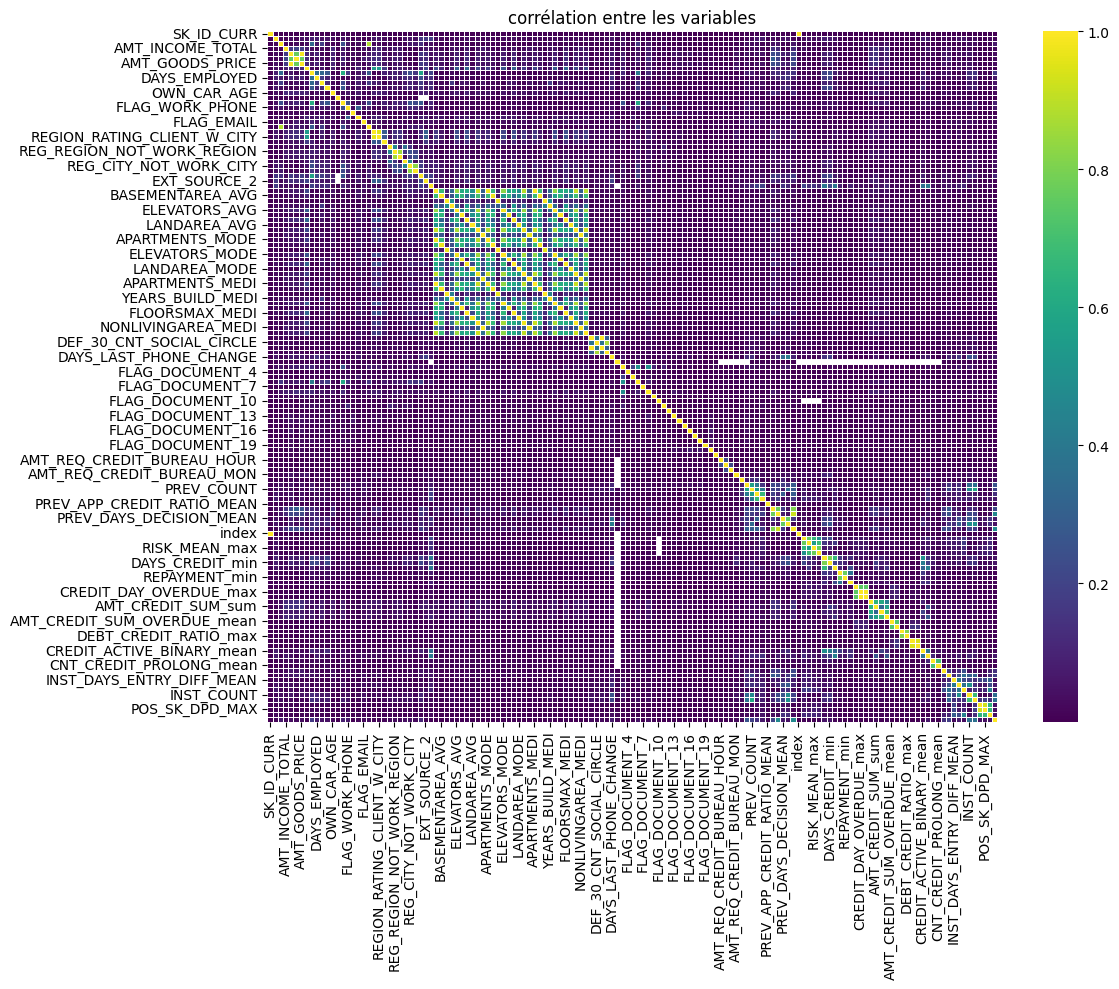

In [82]:
#  heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='viridis', annot=False, fmt=".2f", linewidths=0.5)
plt.title('corrélation entre les variables')
plt.tight_layout()
plt.show()

In [83]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.9
    ]

high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlation'])
high_corr_df = high_corr_df.sort_values(by='Correlation', ascending=False)
high_corr_df.head(20)

,Feature_1,Feature_2,Correlation
39,index,SK_ID_CURR,1.000000
37,OBS_60_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,0.998768
20,YEARS_BUILD_MEDI,YEARS_BUILD_AVG,0.998540
25,FLOORSMAX_MEDI,FLOORSMAX_AVG,0.997004
23,ENTRANCES_MEDI,ENTRANCES_AVG,0.996846
21,ELEVATORS_MEDI,ELEVATORS_AVG,0.996078
30,LIVINGAREA_MEDI,LIVINGAREA_AVG,0.995477
13,APARTMENTS_MEDI,APARTMENTS_AVG,0.995341
18,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,0.994218
16,BASEMENTAREA_MEDI,BASEMENTAREA_AVG,0.994038


Nous remarquons que nous avons des features quasiment identiques. Nous choisisons de supprimer les features ayant une corrélation de plus de 0.98 et nous laissons le model gérer les autres features malgré la forte corrélation entre elles.

In [84]:
to_drop = [col for col in upper.columns if any(upper[col] > 0.98)]
df_final_reduced = df_final_clean.drop(columns=to_drop)

print(f"{len(to_drop)} colonnes supprimées")
print(sorted(to_drop))

15 colonnes supprimées
['AMT_GOODS_PRICE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'CREDIT_DAY_OVERDUE_sum', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE', 'LANDAREA_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAREA_MEDI', 'OBS_60_CNT_SOCIAL_CIRCLE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'index']


In [85]:
df_final_reduced.shape

(356255, 141)

* Nous allons maintenant diviser de nouveau le dataset en train et test ( avec Target et sans Target)

In [86]:
# Train = TARGET connu
df_train = df_final_reduced[df_final_reduced['TARGET'].notna()].copy()

# Test = TARGET inconnu
df_test = df_final_reduced[df_final_reduced['TARGET'].isna()].copy()

print("Train shape :", df_train.shape)
print("Test shape :", df_test.shape)

Train shape : (307511, 141)
Test shape : (48744, 141)


Nous avons maintenant deux nouveau dataframes, un pour train et un en test

In [87]:
print(df_train['TARGET'].value_counts())
print(df_test['TARGET'].unique())  # doit être uniquement NaN

TARGET
0.0    282686
1.0     24825
Name: count, dtype: int64
[nan]


On enregistre les DF train et test prêt pour la modélisation.

In [88]:
save_csv(df_train, "train_clean.csv")
save_csv(df_test, "test_clean.csv")